# Results: RF vs. TabPFN (zero-shot and fine-tuned) Across Information Layers

Combines the RF (subsampled + full), TabPFN zero-shot and TabPFN fine-tuned summary tables into one comparison, runs DeLong's test for AUC-ROC significance (RF vs. TabPFN per layer, fine-tuned vs. zero-shot and vs. RF per layer, and layer vs. layer within each model), and produces the comparison figures used in the results chapters.

In [10]:
from pathlib import Path
from itertools import combinations
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

scripts_dir = (Path.cwd() / ".." / "scripts").resolve()
sys.path.append(str(scripts_dir))

from config import final_data_path

final_data_path = Path(final_data_path)
results_dir = final_data_path / "modeling_results"
rf_dir = results_dir / "rf"
tabpfn_dir = results_dir / "fm"
rf_full_dir = results_dir / "rf_full"
tabpfn_tuned_dir = results_dir / "fm_tuned"
fm_tuned_proba_template = "{key}_tuned_y_proba.npy"

layer_files = [
    "layer_a_bts",
    "layer_b_bts_meteostat",
    "layer_c_bts_gdelt",
    "layer_d_bts_meteostat_gdelt",
]

plt.rcParams.update({
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.grid.axis": "y",
})

metrics = ["f1", "recall", "precision", "auc_roc", "auc_pr", "mcc"]
metric_labels = {
    "f1": "F1", "recall": "Recall", "precision": "Precision",
    "auc_roc": "AUC-ROC", "auc_pr": "AUC-PR", "mcc": "MCC",
}
model_colors = {"RF": "#4C72B0", "TabPFN": "#DD8452", "TabPFN (FT)": "#C44E52", "RF (Full)": "#55A868"}
layer_order = ["A: BTS", "B: BTS+Weather", "C: BTS+GDELT", "D: BTS+Weather+GDELT"]


## 1. Load result summaries

In [11]:
rf_df = pd.read_csv(rf_dir / "rf_subsampled_summary.csv", index_col="layer")
fm_df = pd.read_csv(tabpfn_dir / "fm_subsampled_summary.csv", index_col="layer")
fm_tuned_df = pd.read_csv(tabpfn_tuned_dir / "fm_tuned_summary.csv", index_col="layer")
rf_full_df = pd.read_csv(rf_full_dir / "rf_full_summary.csv", index_col="layer")

fm_tuned_df = fm_tuned_df.rename(columns={"roc_auc": "auc_roc", "pr_auc": "auc_pr"})
missing = set(metrics) - set(fm_tuned_df.columns)
assert not missing, f"fm_tuned_summary.csv is missing metric columns: {missing}"

rf_df["model"] = "RF"
fm_df["model"] = "TabPFN"
fm_tuned_df["model"] = "TabPFN (FT)"
rf_full_df["model"] = "RF (Full)"

print(f"RF: {rf_df.shape} | TabPFN: {fm_df.shape} | TabPFN (FT): {fm_tuned_df.shape} | RF (Full): {rf_full_df.shape}")


RF: (4, 10) | TabPFN: (4, 11) | TabPFN (FT): (4, 18) | RF (Full): (4, 10)


In [12]:
def canonicalize_layer(name: str) -> str:
    name = name.lower()
    has_weather = "meteostat" in name or "weather" in name
    has_gdelt = "gdelt" in name
    if has_weather and has_gdelt:
        return "D: BTS+Weather+GDELT"
    elif has_weather:
        return "B: BTS+Weather"
    elif has_gdelt:
        return "C: BTS+GDELT"
    else:
        return "A: BTS"


for df in (rf_df, fm_df, fm_tuned_df, rf_full_df):
    df["layer_label"] = df.index.map(canonicalize_layer)

sources = {"RF": rf_df, "TabPFN": fm_df, "TabPFN (FT)": fm_tuned_df, "RF (Full)": rf_full_df}
for label, df in sources.items():
    assert set(df["layer_label"]) == set(layer_order), (
        f"{label} doesn't cover the 4 layers (has {sorted(df['layer_label'])}) -- check raw layer names above"
    )
print("OK -- all four sources cover:", layer_order)


OK -- all four sources cover: ['A: BTS', 'B: BTS+Weather', 'C: BTS+GDELT', 'D: BTS+Weather+GDELT']


## 2. Combine into one table

In [13]:
combined_df = pd.concat([
    rf_df.reset_index(drop=True),
    fm_df.reset_index(drop=True),
    fm_tuned_df.reset_index(drop=True),
    rf_full_df.reset_index(drop=True),
])
combined_df.to_csv(results_dir / "rf_vs_fm_combined.csv", index=False)

comparison_table = combined_df.pivot(index="layer_label", columns="model", values=metrics)
comparison_table = comparison_table.reindex(layer_order)
comparison_table = comparison_table.reorder_levels([1, 0], axis=1).sort_index(axis=1, level=0)
comparison_table.to_csv(results_dir / "rf_vs_fm_comparison_table.csv")

comparison_table


model                       RF                                          \
                        auc_pr   auc_roc        f1       mcc precision   
layer_label                                                              
A: BTS                0.356510  0.673140  0.421933  0.207643  0.313103   
B: BTS+Weather        0.369668  0.685567  0.430714  0.225541  0.331093   
C: BTS+GDELT          0.356502  0.677162  0.423714  0.214926  0.326103   
D: BTS+Weather+GDELT  0.367474  0.686012  0.429653  0.226426  0.336769   

model                          RF (Full)                                ...  \
                        recall    auc_pr   auc_roc        f1       mcc  ...   
layer_label                                                             ...   
A: BTS                0.646725  0.361823  0.677831  0.425136  0.214211  ...   
B: BTS+Weather        0.616085  0.373244  0.688841  0.431579  0.229775  ...   
C: BTS+GDELT          0.604726  0.359337  0.679972  0.424262  0.218203  ...   
D: BTS+Weather+GDELT  0.593285  0.370293  0.688929  0.431343  0.230498  ...   

model                   TabPFN                               TabPFN (FT)  \
                            f1       mcc precision    recall      auc_pr   
layer_label                                                                
A: BTS                0.421864  0.206350  0.309389  0.662827    0.361629   
B: BTS+Weather        0.428440  0.216020  0.305810  0.715261    0.371174   
C: BTS+GDELT          0.423720  0.208678  0.307795  0.679728    0.357816   
D: BTS+Weather+GDELT  0.429536  0.219194  0.315336  0.673417    0.363575   

model                                                                   
                       auc_roc        f1       mcc precision    recall  
layer_label                                                             
A: BTS                0.674929  0.421737  0.207801  0.314315  0.640709  
B: BTS+Weather        0.685758  0.431533  0.224965  0.326227  0.637229  
C: BTS+GDELT          0.672528  0.420549  0.204887  0.310639  0.650823  
D: BTS+Weather+GDELT  0.681749  0.428476  0.219315  0.321389  0.642586  

[4 rows x 24 columns]

## 3a. Figure — model comparison across layers (bar chart)

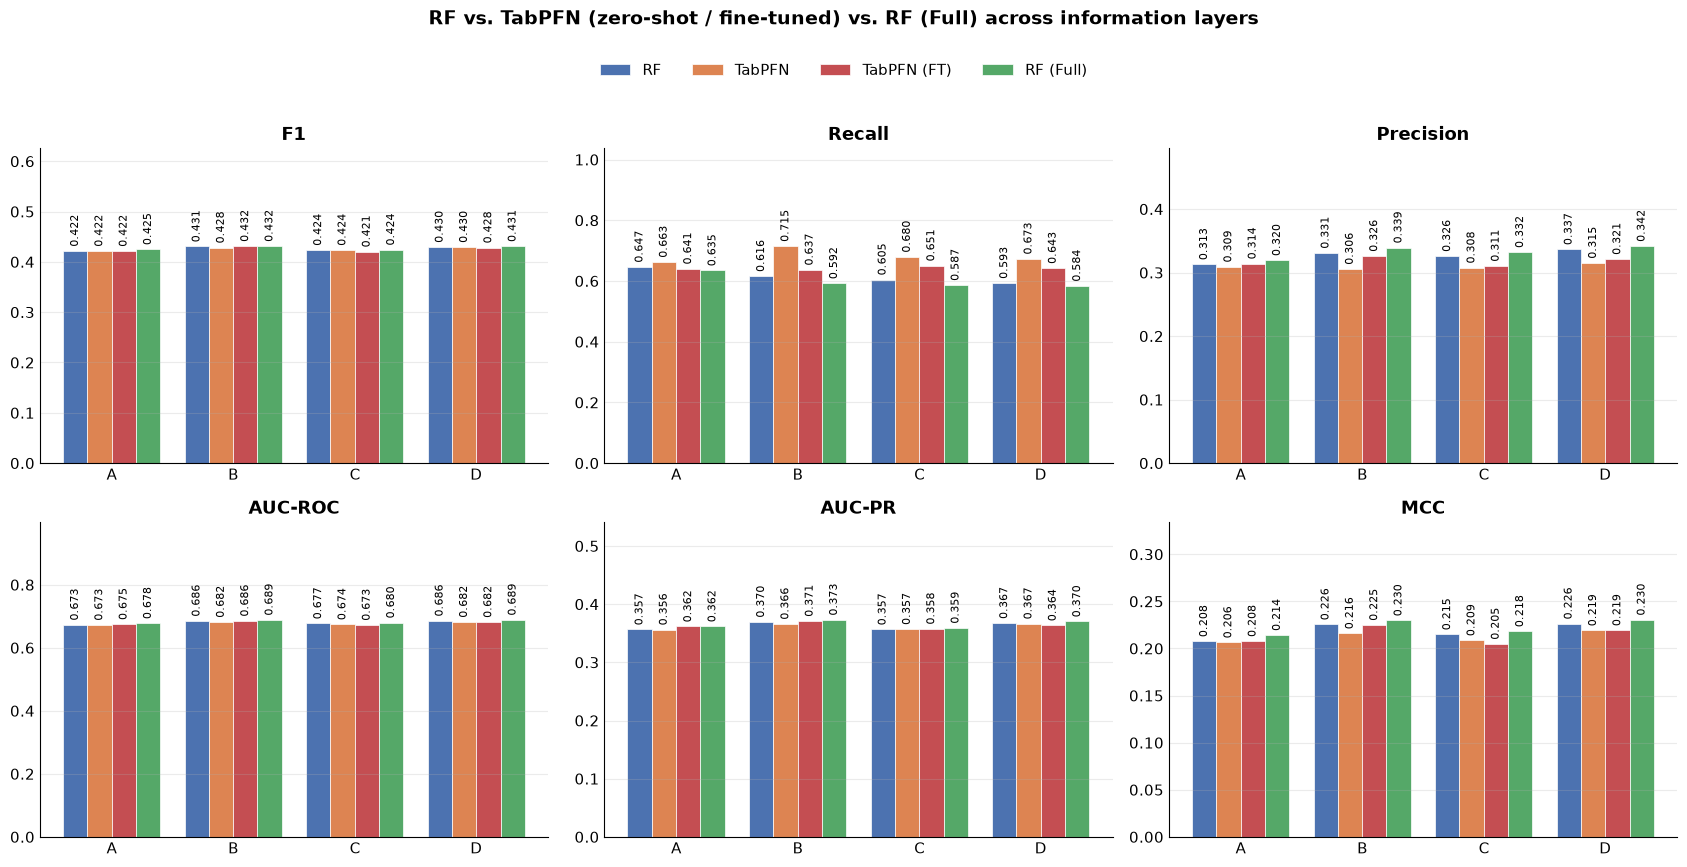

In [14]:
layers = layer_order
models = list(combined_df["model"].unique())
x = np.arange(len(layers))
bar_width = 0.8 / len(models)

fig, axes = plt.subplots(2, 3, figsize=(17, 8))
axes = axes.flatten()

for ax, metric in zip(axes, metrics):
    for i, model in enumerate(models):
        subset = combined_df[combined_df["model"] == model].set_index("layer_label").loc[layers]
        offset = (i - (len(models) - 1) / 2) * bar_width
        bars = ax.bar(
            x + offset, subset[metric], width=bar_width,
            label=model, color=model_colors.get(model), edgecolor="white", linewidth=0.5,
        )
        ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=8, rotation=90)

    ax.set_xticks(x)
    ax.set_xticklabels([l.split(":")[0] for l in layers])
    ax.set_title(metric_labels[metric], fontweight="bold")
    ax.set_ylim(0, max(combined_df[metric].max() * 1.45, 0.15))
    ax.tick_params(axis="both", length=0)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=len(models), bbox_to_anchor=(0.5, 1.03), frameon=False)
fig.suptitle("RF vs. TabPFN (zero-shot / fine-tuned) vs. RF (Full) across information layers", y=1.08, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(results_dir / "rf_vs_fm_metrics.png", dpi=150, bbox_inches="tight")
plt.show()


## 3b. Figure — average model performance across layers (bar chart)

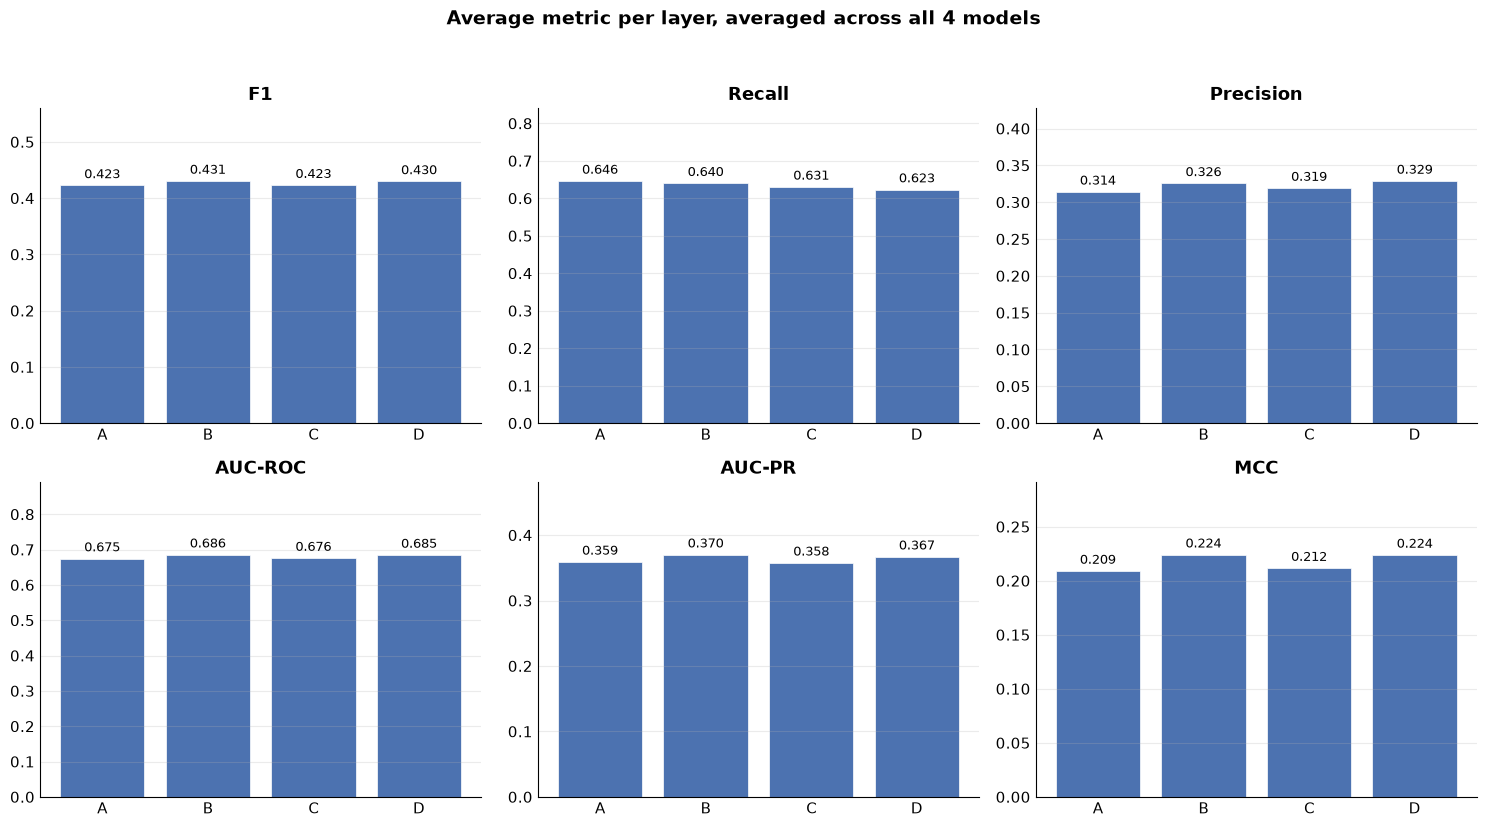

In [15]:
layer_avg_df = combined_df.groupby("layer_label")[metrics].mean().reindex(layer_order)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, metric in zip(axes, metrics):
    bars = ax.bar(
        range(len(layer_order)), layer_avg_df[metric],
        color="#4C72B0", edgecolor="white", linewidth=0.5,
    )
    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)

    ax.set_xticks(range(len(layer_order)))
    ax.set_xticklabels([l.split(":")[0] for l in layer_order])
    ax.set_title(metric_labels[metric], fontweight="bold")
    ax.set_ylim(0, max(layer_avg_df[metric].max() * 1.3, 0.1))
    ax.tick_params(axis="both", length=0)

fig.suptitle(
    f"Average metric per layer, averaged across all {combined_df['model'].nunique()} models",
    y=1.03, fontsize=14, fontweight="bold",
)
plt.tight_layout()
plt.savefig(results_dir / "avg_metrics_by_layer.png", dpi=150, bbox_inches="tight")
plt.show()

## 3c. Figure — average layer performance across models (bar chart)

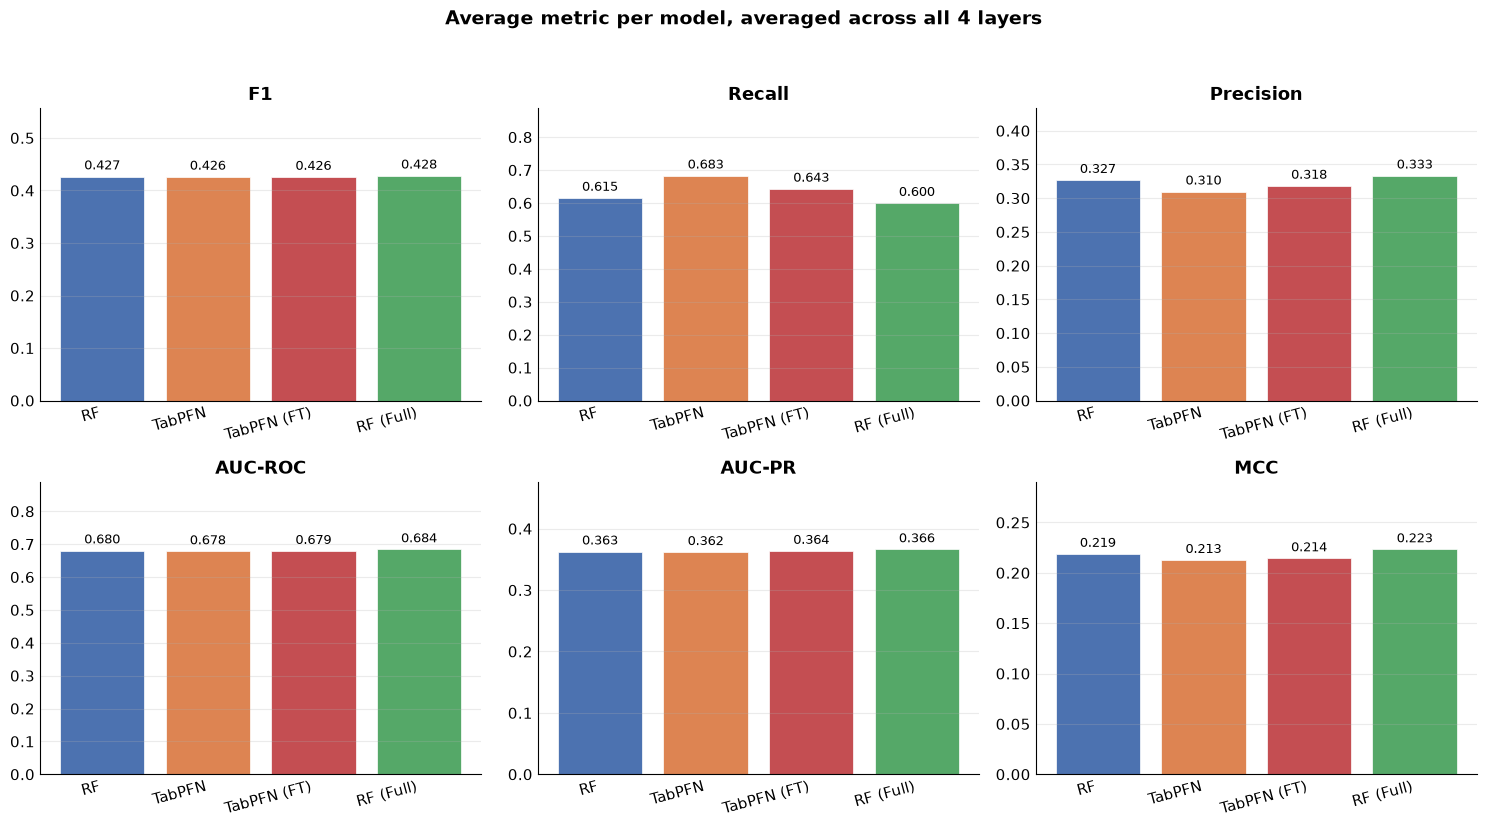

In [16]:
model_order = list(combined_df["model"].unique())
model_avg_df = combined_df.groupby("model")[metrics].mean().reindex(model_order)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, metric in zip(axes, metrics):
    colors = [model_colors.get(m, "#999999") for m in model_order]
    bars = ax.bar(
        range(len(model_order)), model_avg_df[metric],
        color=colors, edgecolor="white", linewidth=0.5,
    )
    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)

    ax.set_xticks(range(len(model_order)))
    ax.set_xticklabels(model_order, rotation=15, ha="right")
    ax.set_title(metric_labels[metric], fontweight="bold")
    ax.set_ylim(0, max(model_avg_df[metric].max() * 1.3, 0.1))
    ax.tick_params(axis="both", length=0)

fig.suptitle(
    f"Average metric per model, averaged across all {len(layer_order)} layers",
    y=1.03, fontsize=14, fontweight="bold",
)
plt.tight_layout()
plt.savefig(results_dir / "avg_metrics_by_model.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. DeLong's test — setup



In [17]:
def compute_midrank(x):
    """Ranks, with ties broken by averaging (needed for DeLong's variance formula)."""
    J = np.argsort(x)
    Z = x[J]
    N = len(x)
    T = np.zeros(N, dtype=float)
    i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1
        T[i:j] = 0.5 * (i + j - 1) + 1
        i = j
    T2 = np.empty(N, dtype=float)
    T2[J] = T
    return T2


def fastDeLong(predictions_sorted_transposed, label_1_count):
    """Core DeLong covariance computation.
    predictions_sorted_transposed: (n_models, n_examples), positive-class examples first."""
    m = label_1_count
    n = predictions_sorted_transposed.shape[1] - m
    positive_examples = predictions_sorted_transposed[:, :m]
    negative_examples = predictions_sorted_transposed[:, m:]
    k = predictions_sorted_transposed.shape[0]

    tx = np.empty([k, m], dtype=float)
    ty = np.empty([k, n], dtype=float)
    tz = np.empty([k, m + n], dtype=float)
    for r in range(k):
        tx[r, :] = compute_midrank(positive_examples[r, :])
        ty[r, :] = compute_midrank(negative_examples[r, :])
        tz[r, :] = compute_midrank(predictions_sorted_transposed[r, :])

    aucs = tz[:, :m].sum(axis=1) / m / n - float(m + 1.0) / (2.0 * n)
    v01 = (tz[:, :m] - tx[:, :]) / n
    v10 = 1.0 - (tz[:, m:] - ty[:, :]) / m
    sx = np.cov(v01)
    sy = np.cov(v10)
    delongcov = sx / m + sy / n
    return aucs, delongcov


def delong_roc_test(y_true, proba_a, proba_b):
    """Two-sided DeLong's test comparing two paired probability sets against the
    same ground truth. Returns (auc_a, auc_b, p_value)."""
    y_true = np.asarray(y_true)
    order = np.argsort(-y_true)  # positives first
    label_1_count = int(y_true.sum())

    preds = np.vstack([proba_a, proba_b])[:, order]
    aucs, delongcov = fastDeLong(preds, label_1_count)

    auc_diff = aucs[0] - aucs[1]
    var = delongcov[0, 0] + delongcov[1, 1] - 2 * delongcov[0, 1]
    z = auc_diff / np.sqrt(var)
    p_value = 2 * (1 - stats.norm.cdf(abs(z)))
    return aucs[0], aucs[1], p_value


## 5. DeLong's test — RF vs. TabPFN, per layer

In [18]:
delong_results = []

for name in layer_files:
    key = f"{name}_subsampled"

    rf_data = np.load(rf_dir / f"{key}_probs.npz")
    y_test_rf, rf_proba = rf_data["y_test"], rf_data["test_proba"]

    fm_proba = np.load(tabpfn_dir / f"{key}_y_proba.npy")

    assert len(y_test_rf) == len(fm_proba), (
        f"{key}: RF y_test length ({len(y_test_rf)}) != TabPFN proba length "
        f"({len(fm_proba)}) -- these aren't the same test set, stop and check"
    )

    auc_rf, auc_fm, p_value = delong_roc_test(y_test_rf, rf_proba, fm_proba)
    delong_results.append({
        "layer": key, "auc_rf": auc_rf, "auc_fm": auc_fm,
        "auc_diff": auc_fm - auc_rf, "p_value": p_value,
        "significant_at_0.05": p_value < 0.05,
    })
    print(f"{key}: AUC RF={auc_rf:.4f}, TabPFN={auc_fm:.4f}, "
          f"diff={auc_fm - auc_rf:+.4f}, p={p_value:.4f}")

delong_df = pd.DataFrame(delong_results)
delong_df.to_csv(results_dir / "delong_rf_vs_tabpfn.csv", index=False)
delong_df


layer_a_bts_subsampled: AUC RF=0.6731, TabPFN=0.6728, diff=-0.0004, p=0.0011


KeyboardInterrupt: 

## 5b. DeLong's test — fine-tuned TabPFN vs. zero-shot TabPFN and vs. RF, per layer

Does fine-tuning buy a significant AUC-ROC gain over the zero-shot model, and does it close the gap to RF? Same paired test set as above.

In [ ]:
def load_tuned_proba(key):
    path = tabpfn_tuned_dir / fm_tuned_proba_template.format(key=key)
    if not path.exists():
        print(f"  !! missing {path.name} -- skipping {key}")
        return None
    return np.load(path)


ft_results = []

for name in layer_files:
    key = f"{name}_subsampled"
    rf_data = np.load(rf_dir / f"{key}_probs.npz")
    y_test, rf_proba = rf_data["y_test"], rf_data["test_proba"]
    zs_proba = np.load(tabpfn_dir / f"{key}_y_proba.npy")
    ft_proba = load_tuned_proba(key)
    if ft_proba is None:
        continue
    assert len(ft_proba) == len(y_test), (
        f"{key}: fine-tuned proba length ({len(ft_proba)}) != y_test length ({len(y_test)})"
    )

    for ref_label, ref_proba in [("TabPFN", zs_proba), ("RF", rf_proba)]:
        auc_ref, auc_ft, p_value = delong_roc_test(y_test, ref_proba, ft_proba)
        ft_results.append({
            "layer": key, "comparison": f"TabPFN (FT) vs {ref_label}",
            "auc_ref": auc_ref, "auc_ft": auc_ft, "auc_diff": auc_ft - auc_ref,
            "p_value": p_value, "significant_at_0.05": p_value < 0.05,
        })
        print(f"{key}: FT vs {ref_label}: AUC {ref_label}={auc_ref:.4f}, FT={auc_ft:.4f}, "
              f"diff={auc_ft - auc_ref:+.4f}, p={p_value:.4f}")

ft_delong_df = pd.DataFrame(ft_results)
ft_delong_df.to_csv(results_dir / "delong_tabpfn_ft.csv", index=False)
ft_delong_df


  !! missing layer_a_bts_subsampled_tuned_y_proba.npy -- skipping layer_a_bts_subsampled
  !! missing layer_b_bts_meteostat_subsampled_tuned_y_proba.npy -- skipping layer_b_bts_meteostat_subsampled
  !! missing layer_c_bts_gdelt_subsampled_tuned_y_proba.npy -- skipping layer_c_bts_gdelt_subsampled
  !! missing layer_d_bts_meteostat_gdelt_subsampled_tuned_y_proba.npy -- skipping layer_d_bts_meteostat_gdelt_subsampled


""


## 6. DeLong's test — layer vs. layer, within each model

All 4 layers share the same underlying 2025 flights, so every comparison is paired on identical ground truth — only the feature set feeding the model changes.

In [ ]:
def load_probs(key, model):
    if model == "RF":
        data = np.load(rf_dir / f"{key}_probs.npz")
        return data["y_test"], data["test_proba"]
    elif model == "TabPFN":
        rf_data = np.load(rf_dir / f"{key}_probs.npz")  # borrow y_test, same flights
        fm_proba = np.load(tabpfn_dir / f"{key}_y_proba.npy")
        return rf_data["y_test"], fm_proba
    elif model == "TabPFN (FT)":
        rf_data = np.load(rf_dir / f"{key}_probs.npz")
        return rf_data["y_test"], load_tuned_proba(key)
    else:
        raise ValueError(model)


layer_pair_results = []

# TabPFN (FT) only joins the layer-pair tests if all 4 layers' probabilities exist
pair_models = ["RF", "TabPFN"]
if all((tabpfn_tuned_dir / fm_tuned_proba_template.format(key=f"{n}_subsampled")).exists() for n in layer_files):
    pair_models.append("TabPFN (FT)")
else:
    print("!! Fine-tuned probabilities incomplete -- TabPFN (FT) left out of layer-pair tests")

for model in pair_models:
    layer_data = {f"{name}_subsampled": load_probs(f"{name}_subsampled", model) for name in layer_files}

    for key_a, key_b in combinations(layer_data.keys(), 2):
        y_test_a, proba_a = layer_data[key_a]
        y_test_b, proba_b = layer_data[key_b]

        assert len(y_test_a) == len(y_test_b) and np.array_equal(y_test_a, y_test_b), (
            f"{model} {key_a} vs {key_b}: y_test arrays don't match -- can't run "
            f"a paired DeLong's test on mismatched ground truth"
        )

        auc_a, auc_b, p_value = delong_roc_test(y_test_a, proba_a, proba_b)
        layer_pair_results.append({
            "model": model, "layer_a": key_a, "layer_b": key_b,
            "auc_a": auc_a, "auc_b": auc_b, "auc_diff": auc_b - auc_a,
            "p_value": p_value, "significant_at_0.05": p_value < 0.05,
        })

layer_pair_df = pd.DataFrame(layer_pair_results)
layer_pair_df


!! Fine-tuned probabilities incomplete -- TabPFN (FT) left out of layer-pair tests


,model,layer_a,layer_b,auc_a,auc_b,auc_diff,p_value,significant_at_0.05
0,RF,layer_a_bts_subsampled,layer_b_bts_meteostat_subsampled,0.673140,0.685567,0.012427,0.000000e+00,True
1,RF,layer_a_bts_subsampled,layer_c_bts_gdelt_subsampled,0.673140,0.677162,0.004022,0.000000e+00,True
2,RF,layer_a_bts_subsampled,layer_d_bts_meteostat_gdelt_subsampled,0.673140,0.686012,0.012872,0.000000e+00,True
3,RF,layer_b_bts_meteostat_subsampled,layer_c_bts_gdelt_subsampled,0.685567,0.677162,-0.008405,0.000000e+00,True
4,RF,layer_b_bts_meteostat_subsampled,layer_d_bts_meteostat_gdelt_subsampled,0.685567,0.686012,0.000445,3.506595e-10,True
5,RF,layer_c_bts_gdelt_subsampled,layer_d_bts_meteostat_gdelt_subsampled,0.677162,0.686012,0.008850,0.000000e+00,True
6,TabPFN,layer_a_bts_subsampled,layer_b_bts_meteostat_subsampled,0.673869,0.684213,0.010344,0.000000e+00,True
7,TabPFN,layer_a_bts_subsampled,layer_c_bts_gdelt_subsampled,0.673869,0.673492,-0.000377,3.371303e-12,True
8,TabPFN,layer_a_bts_subsampled,layer_d_bts_meteostat_gdelt_subsampled,0.673869,0.681763,0.007894,0.000000e+00,True
9,TabPFN,layer_b_bts_meteostat_subsampled,layer_c_bts_gdelt_subsampled,0.684213,0.673492,-0.010721,0.000000e+00,True


## 7. Bonferroni correction

In [ ]:
n_comparisons = len(layer_pair_df)
bonferroni_alpha = 0.05 / n_comparisons
layer_pair_df["significant_bonferroni"] = layer_pair_df["p_value"] < bonferroni_alpha

print(f"Raw alpha: 0.05 | Bonferroni-corrected alpha: {bonferroni_alpha:.5f} "
      f"(0.05 / {n_comparisons} comparisons)")

layer_pair_df.to_csv(results_dir / "delong_layer_pairs.csv", index=False)
layer_pair_df[["model", "layer_a", "layer_b", "auc_diff", "p_value",
               "significant_at_0.05", "significant_bonferroni"]]


Raw alpha: 0.05 | Bonferroni-corrected alpha: 0.00417 (0.05 / 12 comparisons)


,model,layer_a,layer_b,auc_diff,p_value,significant_at_0.05,significant_bonferroni
0,RF,layer_a_bts_subsampled,layer_b_bts_meteostat_subsampled,0.012427,0.000000e+00,True,True
1,RF,layer_a_bts_subsampled,layer_c_bts_gdelt_subsampled,0.004022,0.000000e+00,True,True
2,RF,layer_a_bts_subsampled,layer_d_bts_meteostat_gdelt_subsampled,0.012872,0.000000e+00,True,True
3,RF,layer_b_bts_meteostat_subsampled,layer_c_bts_gdelt_subsampled,-0.008405,0.000000e+00,True,True
4,RF,layer_b_bts_meteostat_subsampled,layer_d_bts_meteostat_gdelt_subsampled,0.000445,3.506595e-10,True,True
5,RF,layer_c_bts_gdelt_subsampled,layer_d_bts_meteostat_gdelt_subsampled,0.008850,0.000000e+00,True,True
6,TabPFN,layer_a_bts_subsampled,layer_b_bts_meteostat_subsampled,0.010344,0.000000e+00,True,True
7,TabPFN,layer_a_bts_subsampled,layer_c_bts_gdelt_subsampled,-0.000377,3.371303e-12,True,True
8,TabPFN,layer_a_bts_subsampled,layer_d_bts_meteostat_gdelt_subsampled,0.007894,0.000000e+00,True,True
9,TabPFN,layer_b_bts_meteostat_subsampled,layer_c_bts_gdelt_subsampled,-0.010721,0.000000e+00,True,True


## 8. Figure — pairwise layer AUC-ROC significance (new)

The layer-pair DeLong results above were only ever a table. This heatmap makes the same numbers scannable: which layer differences are real, not just numerically bigger. Diverging color = AUC-ROC difference (row layer − column layer); `**` = Bonferroni-significant, `*` = significant only at the uncorrected 0.05 level.

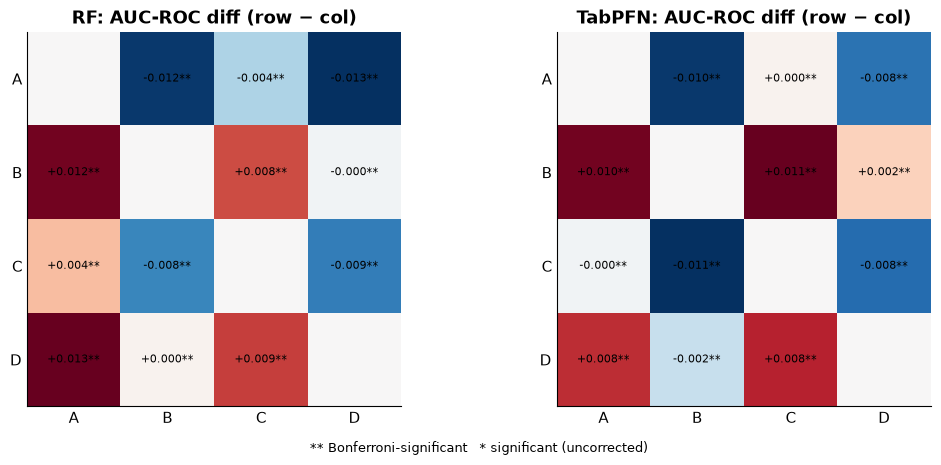

In [ ]:
def build_diff_matrix(model):
    sub = layer_pair_df[layer_pair_df["model"] == model]
    mat = pd.DataFrame(np.nan, index=LAYER_ORDER, columns=LAYER_ORDER)
    star = pd.DataFrame("", index=LAYER_ORDER, columns=LAYER_ORDER)
    label_of = {f"{n}_subsampled": canonicalize_layer(n) for n in layer_files}

    for _, row in sub.iterrows():
        a, b = label_of[row["layer_a"]], label_of[row["layer_b"]]
        mat.loc[b, a] = row["auc_diff"]
        mat.loc[a, b] = -row["auc_diff"]
        mark = "**" if row["significant_bonferroni"] else ("*" if row["significant_at_0.05"] else "")
        star.loc[b, a] = mark
        star.loc[a, b] = mark
    for l in LAYER_ORDER:  # (fill_diagonal on .values breaks under pandas copy-on-write)
        mat.loc[l, l] = 0.0
    return mat, star


fig, axes = plt.subplots(1, len(PAIR_MODELS), figsize=(5.5 * len(PAIR_MODELS), 4.5))

for ax, model in zip(np.atleast_1d(axes), PAIR_MODELS):
    mat, star = build_diff_matrix(model)
    vmax = np.nanmax(np.abs(mat.values))
    im = ax.imshow(mat.values, cmap="RdBu_r", vmin=-vmax, vmax=vmax)

    for i in range(len(LAYER_ORDER)):
        for j in range(len(LAYER_ORDER)):
            if i == j:
                continue
            val = mat.values[i, j]
            ax.text(j, i, f"{val:+.3f}{star.values[i, j]}", ha="center", va="center", fontsize=8)

    ax.set_xticks(range(len(LAYER_ORDER)))
    ax.set_yticks(range(len(LAYER_ORDER)))
    ax.set_xticklabels([l.split(":")[0] for l in LAYER_ORDER])
    ax.set_yticklabels([l.split(":")[0] for l in LAYER_ORDER])
    ax.set_title(f"{model}: AUC-ROC diff (row − col)", fontweight="bold")
    ax.tick_params(axis="both", length=0)
    ax.grid(False)

fig.text(0.5, -0.02, "** Bonferroni-significant   * significant (uncorrected)", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig(results_dir / "delong_layer_pairs_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
